# Práctica 2 · Preparar los documentos

En la práctica anterior armaste un sistema RAG que funcionaba, y al final quedó una lista de
cosas que le faltaban. La primera de todas era esta: el texto entraba sucio.

Hoy vamos a resolverlo, y de paso a entender por qué esta parte del trabajo decide la calidad
de todo lo demás. Un error aquí no se arregla después: si el texto que guardas está revuelto,
la búsqueda va a recuperar basura y el modelo va a responder sobre basura, por muy bueno que
sea el modelo.

Este es el primero de los dos flujos que tiene cualquier sistema RAG. Se corre una sola vez por
documento, cuando llega material nuevo o cuando el que había cambió. El otro flujo, el que
responde preguntas, es el de la práctica siguiente.

<img src="figuras/03_flujo_ingesta.svg" alt="Diagrama del flujo de preparación de documentos: del documento original se extrae el texto separándolo de tablas e imágenes, se le agregan metadatos, se fragmenta y se deja listo para vectorizar." width="880">

Dos etapas, entonces. Primero separar el contenido que nos sirve del que no, que se llama
parseo. Después partirlo en pedazos del tamaño adecuado, que se llama fragmentación.

Las celdas se ejecutan en orden, una por una, con Shift + Enter.

## 1. Instalar las librerías

Tres librerías nuevas respecto a la práctica anterior.

`pymupdf` lee PDF con mucho más detalle que `pypdf`: distingue bloques de texto, encuentra
tablas y saca imágenes. `python-docx` hace lo propio con archivos de Word. `spacy` sabe dónde
termina una oración de verdad, que no es lo mismo que buscar puntos.

`spacy` necesita además un modelo de idioma aparte, y bajamos dos: el de español, que es el del
documento con el que vamos a trabajar, y el de inglés, para comparar qué pasa cuando uno usa el
modelo equivocado. Ya verás que no es un detalle.

In [1]:
%pip install --quiet pymupdf python-docx spacy openpyxl pandas
%pip install --quiet https://github.com/explosion/spacy-models/releases/download/es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl
%pip install --quiet https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

print("Librerías listas.")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/fgrodriguez/ESAN_GlobalWeek2026/09_Notebooks_RAG/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/fgrodriguez/ESAN_GlobalWeek2026/09_Notebooks_RAG/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/fgrodriguez/ESAN_GlobalWeek2026/09_Notebooks_RAG/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Librerías listas.


## 2. Comprobar que Ollama responde

Ollama es el programa que ejecuta los modelos de lenguaje dentro de tu computadora. Tiene que
estar encendido para que este cuaderno funcione, así que lo primero es confirmarlo.

Si algo falla, la salida de la celda te dice qué hacer según tu sistema operativo.

In [2]:
import platform
import sys

import requests

OLLAMA_URL = "http://localhost:11434"

print(f"Sistema: {platform.system()} {platform.machine()}")
print(f"Python:  {sys.version.split()[0]}\n")

try:
    respuesta = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
    respuesta.raise_for_status()
    modelos = sorted(m["name"] for m in respuesta.json()["models"])
    print(f"Ollama responde. Tienes {len(modelos)} modelos descargados:\n")
    for m in modelos:
        print(f"  - {m}")
except Exception as e:
    print(f"Ollama no responde en {OLLAMA_URL}")
    print(f"Detalle: {type(e).__name__}\n")
    if platform.system() == "Darwin":
        print("En Mac: abre la aplicación Ollama desde la carpeta Aplicaciones.")
        print("Debe aparecer su ícono en la barra de menús, arriba a la derecha.")
    elif platform.system() == "Windows":
        print("En Windows: busca Ollama en el menú Inicio y ábrelo.")
        print("Debe aparecer su ícono junto al reloj, abajo a la derecha.")
    else:
        print("Ejecuta 'ollama serve' en una terminal.")

Sistema: Darwin arm64
Python:  3.12.13

Ollama responde. Tienes 14 modelos descargados:

  - embeddinggemma:300m
  - gemma3:1b
  - gemma3:4b
  - gemma4:12b-mlx
  - gemma4:26b
  - gemma4:e4b
  - granite4.1:3b
  - granite4.1:8b
  - mxbai-embed-large:latest
  - nemotron-mini:4b
  - nomic-embed-text:latest
  - qwen3-4b-cs-ft:latest
  - qwen3:4b
  - shieldgemma:2b


## 3. Elegir el modelo según tu equipo

El modelo va a correr en tu máquina, así que la memoria que tengas importa. Un modelo grande
en un equipo chico no se rompe: simplemente tarda muchísimo y el sistema se pone lento.

Abajo hay tres opciones. Deja activa una sola, la que corresponda a tu computadora, y comenta
las demás poniéndoles un signo de gato al inicio de la línea. Si no sabes cuánta memoria
tienes, quédate con la opción A, que funciona en cualquier equipo.

El modelo de embeddings no se elige por equipo: es ligero y va igual en todos. Sí conviene saber
de dónde salió esa elección, y la respuesta es que está medida con documentos en español; en la
práctica 3 vas a reproducir la medición y a ver a los tres candidatos compitiendo.

In [3]:
# ---- Opción A: equipos de 8 GB de memoria o menos (descarga 3.3 GB) ---------
MODELO_LLM = "gemma3:4b"

# ---- Opción B: equipos de 16 GB de memoria (descarga 10 GB) ----------------
# MODELO_LLM = "gemma4:12b"        # Windows y Linux
# MODELO_LLM = "gemma4:12b-mlx"    # Mac con chip Apple (M1 en adelante), va más rápido

# ---- Opción C: equipos de 32 GB de memoria o más (descarga 17 GB) ----------
# MODELO_LLM = "gemma4:26b"        # Windows y Linux
# MODELO_LLM = "gemma4:26b-mlx"    # Mac con chip Apple

# El modelo de embeddings es ligero y es el mismo para todos. La elección está
# medida, no copiada de un tutorial: lo comprobamos en la práctica 3. Se eligió
# éste porque es el único de los tres que encuentra un pasaje en inglés cuando la
# pregunta va en español, algo que hace falta en cuanto el corpus mezcla idiomas.
MODELO_EMBEDDINGS = "embeddinggemma:300m"

print(f"Modelo de lenguaje:   {MODELO_LLM}")
print(f"Modelo de embeddings: {MODELO_EMBEDDINGS}")
print("\nSi alguno no aparece en la lista de la celda anterior, descárgalo con:")
print(f"   ollama pull {MODELO_LLM}")
print(f"   ollama pull {MODELO_EMBEDDINGS}")

Modelo de lenguaje:   gemma3:4b
Modelo de embeddings: embeddinggemma:300m

Si alguno no aparece en la lista de la celda anterior, descárgalo con:
   ollama pull gemma3:4b
   ollama pull embeddinggemma:300m


## 4. El documento con el que vamos a trabajar

Cambiamos de material. En lugar de una novela usaremos algo parecido a lo que te vas a
encontrar en el trabajo: una política de envíos y devoluciones de una tienda en línea, con
párrafos, un cuadro de plazos y costos, y una gráfica.

Ese cuadro es la parte interesante. Es donde está la información más consultada por los
clientes, y es justo lo que peor sobrevive a una extracción descuidada.

In [4]:
import warnings
warnings.filterwarnings("ignore", message=".*langchain-community.*")

from pathlib import Path

import pymupdf

# Path() nombra un archivo del disco sin preocuparse de si el sistema separa las
# carpetas con / o con la barra invertida. pymupdf.open lo abre para leerlo.
PDF = Path("documentos/tiendasol_politicas.pdf")
doc = pymupdf.open(PDF)

print(f"Archivo: {PDF.name}")
print(f"Páginas: {len(doc)}")
print(f"Metadatos del archivo: {doc.metadata.get('producer', 'sin dato')}")

for pagina in doc:
    # Antes de extraer nada conviene saber qué hay dentro de cada página: cuántas
    # tablas y cuántas imágenes. Lo que no se inventaría se pierde sin avisar.
    tablas = pagina.find_tables()
    print(f"\nPágina {pagina.number}: "
          f"{len(tablas.tables)} tabla(s), {len(pagina.get_images())} imagen(es)")

Archivo: tiendasol_politicas.pdf
Páginas: 2
Metadatos del archivo: 
Consider using the pymupdf_layout package for a greatly improved page layout analysis.

Página 0: 1 tabla(s), 1 imagen(es)

Página 1: 0 tabla(s), 0 imagen(es)


## 5. Extraer el texto: la vía simple y su problema

Esta es la forma más directa de sacar texto de un PDF, y la que usa casi todo el mundo la
primera vez. Funciona, pero mira con cuidado lo que devuelve.

In [5]:
pagina = doc[0]
# get_text() es la forma más directa de sacar el texto. Funciona, pero devuelve todo
# revuelto: el texto corrido y el de las tablas mezclados en una sola cadena.
texto_simple = pagina.get_text()

print(texto_simple[:1200])

TiendaSol · Politica de envios y devoluciones
Centro de Ayuda · version 1.2 · junio 2026
Este documento reune las condiciones de envio, los plazos de entrega y el procedimiento de devolucion
vigentes para todas las compras realizadas en la tienda en linea de TiendaSol. Aplica a pedidos entregados
dentro del territorio nacional y complementa los terminos y condiciones generales del servicio.
Los plazos de entrega se cuentan en dias habiles a partir de la confirmacion del pago, no de la fecha en que se
coloco el pedido. Cuando un pedido incluye productos de distinta procedencia, el plazo aplicable es el del
producto con mayor tiempo de preparacion. Los pedidos confirmados despues de las 14:00 horas se procesan
el siguiente dia habil.
Cuadro 1. Plazos y costos de envio por zona
Zona
Plazo habil
Costo
Envio gratis desde
Lima metropolitana
1 a 2 dias
S/ 9.90
S/ 99
Provincias, capital
3 a 5 dias
S/ 15.90
S/ 149
Provincias, interior
5 a 8 dias
S/ 22.90
S/ 199
Zona de selva
8 a 12 dias
S/ 29.9

¿Ves el problema? El cuadro de plazos quedó deshecho. Sus celdas se convirtieron en una
sucesión de líneas suelas, revueltas con los párrafos, y perdieron lo único que las hacía
comprensibles: a qué fila y a qué columna pertenecía cada valor.

Un fragmento que diga "Lima metropolitana, 1 a 2 dias, S/ 9.90" es útil. Uno que diga
"Lima metropolitana" seguido de "Selva" y luego de un montón de números sin encabezado no le
sirve ni a la búsqueda ni al modelo. Y es peor que inútil: puede hacer que el modelo asocie el
costo equivocado a la zona equivocada.

Un PDF no guarda párrafos ni tablas. Guarda caracteres con coordenadas. Todo lo que parece
estructura al verlo en pantalla es un efecto visual que hay que reconstruir.

## 6. Extraer por bloques

Un primer avance. PyMuPDF puede agrupar el texto en bloques, según la cercanía física de los
caracteres en la página. Un bloque suele corresponder a un párrafo, a un título, o a una celda.

In [6]:
# Con "blocks" el mismo texto llega separado en trozos, según cómo estaba puesto en
# la página. Cada bloque trae sus coordenadas y su contenido; el contenido está en
# la posición 4 de cada bloque, que es la que se usa abajo.
bloques = pagina.get_text("blocks")

print(f"La página se separó en {len(bloques)} bloques.\n")
for i, bloque in enumerate(bloques[:8]):
    contenido = " ".join(bloque[4].split())
    print(f"[{i}] {contenido[:90]}")

La página se separó en 23 bloques.

[0] TiendaSol · Politica de envios y devoluciones
[1] Centro de Ayuda · version 1.2 · junio 2026
[2] Este documento reune las condiciones de envio, los plazos de entrega y el procedimiento de
[3] vigentes para todas las compras realizadas en la tienda en linea de TiendaSol. Aplica a pe
[4] dentro del territorio nacional y complementa los terminos y condiciones generales del serv
[5] Los plazos de entrega se cuentan en dias habiles a partir de la confirmacion del pago, no 
[6] coloco el pedido. Cuando un pedido incluye productos de distinta procedencia, el plazo apl
[7] producto con mayor tiempo de preparacion. Los pedidos confirmados despues de las 14:00 hor


Ya se distingue mejor dónde empieza y termina cada cosa. Pero seguimos sin saber cuáles de
esos bloques eran parte del cuadro y cuáles eran texto corrido. Para eso hay que preguntarle
por las tablas directamente.

## 7. Separar las tablas

PyMuPDF sabe detectar tablas y devolverlas como filas y columnas, que es la forma en que
realmente significan algo.

In [7]:
# find_tables() detecta las tablas por su trazado, y extract() devuelve cada una como
# una lista de filas, con cada fila como una lista de celdas.
tablas = pagina.find_tables()
print(f"Tablas encontradas: {len(tablas.tables)}\n")

for numero, tabla in enumerate(tablas.tables, 1):
    filas = tabla.extract()
    print(f"--- Tabla {numero}: {len(filas)} filas x {len(filas[0])} columnas ---")
    for fila in filas:
        print("   ", fila)

Tablas encontradas: 1

--- Tabla 1: 5 filas x 4 columnas ---
    ['Zona', 'Plazo habil', 'Costo', 'Envio gratis desde']
    ['Lima metropolitana', '1 a 2 dias', 'S/ 9.90', 'S/ 99']
    ['Provincias, capital', '3 a 5 dias', 'S/ 15.90', 'S/ 149']
    ['Provincias, interior', '5 a 8 dias', 'S/ 22.90', 'S/ 199']
    ['Zona de selva', '8 a 12 dias', 'S/ 29.90', 'S/ 249']


Eso ya es información aprovechable. Con las filas y columnas identificadas puedes convertir el
cuadro a un texto que conserve el sentido, en lugar de dejarlo como una lista de valores
sueltos.

La forma de hacerlo depende de para qué lo quieras. Aquí lo convertimos en una frase por fila,
que es lo que mejor funciona cuando el fragmento va a ser recuperado por significado.

In [8]:
def tabla_a_frases(filas):
    """Convierte una tabla en una frase por fila, conservando los encabezados."""
    encabezados = filas[0]
    frases = []
    for fila in filas[1:]:
        partes = [f"{enc}: {val}" for enc, val in zip(encabezados, fila) if val]
        frases.append("; ".join(partes))
    return frases


# Así se ve la diferencia: la misma tabla, pero ahora cada fila se explica sola.
for frase in tabla_a_frases(tablas.tables[0].extract()):
    print("-", frase)

- Zona: Lima metropolitana; Plazo habil: 1 a 2 dias; Costo: S/ 9.90; Envio gratis desde: S/ 99
- Zona: Provincias, capital; Plazo habil: 3 a 5 dias; Costo: S/ 15.90; Envio gratis desde: S/ 149
- Zona: Provincias, interior; Plazo habil: 5 a 8 dias; Costo: S/ 22.90; Envio gratis desde: S/ 199
- Zona: Zona de selva; Plazo habil: 8 a 12 dias; Costo: S/ 29.90; Envio gratis desde: S/ 249


Compara esta salida con la de la sección 5. La misma información, pero ahora cada línea se
sostiene sola: dice de qué zona habla, cuánto tarda y cuánto cuesta. Si la búsqueda recupera
una de estas líneas, el modelo tiene todo lo que necesita.

## 8. Texto sin tablas

Nos falta la otra mitad: quedarnos con el texto corrido, esta vez sin los pedazos del cuadro
revueltos dentro.

La estrategia es sacar primero el contenido de las tablas, y después filtrar del texto
completo todas las líneas que pertenezcan a ellas.

In [9]:
# El problema: el texto de las tablas también aparece en get_text(), así que si se
# guardan las dos cosas la información entra duplicada al corpus. Esta función
# recorta el área de cada tabla y descarta las líneas que ya salieron ahí dentro.
def texto_sin_tablas(documento):
    """Devuelve el texto corrido de un PDF, excluyendo el contenido de las tablas."""
    resultado = []

    for pagina in documento:
        texto_tablas = []
        for tabla in pagina.find_tables().tables:
            texto_tablas.append(pagina.get_text(clip=tabla.bbox))

        lineas_limpias = []
        for linea in pagina.get_text().split("\n"):
            linea = linea.strip()
            if not linea:
                continue
            if any(linea in bloque for bloque in texto_tablas):
                continue
            lineas_limpias.append(linea)

        if lineas_limpias:
            resultado.append("\n".join(lineas_limpias))

    return "\n\n".join(resultado)


corrido = texto_sin_tablas(doc)
print(f"Texto corrido: {len(corrido)} caracteres\n")
print(corrido[:900])

Texto corrido: 2136 caracteres

TiendaSol · Politica de envios y devoluciones
Centro de Ayuda · version 1.2 · junio 2026
Este documento reune las condiciones de envio, los plazos de entrega y el procedimiento de devolucion
vigentes para todas las compras realizadas en la tienda en linea de TiendaSol. Aplica a pedidos entregados
dentro del territorio nacional y complementa los terminos y condiciones generales del servicio.
Los plazos de entrega se cuentan en dias habiles a partir de la confirmacion del pago, no de la fecha en que se
coloco el pedido. Cuando un pedido incluye productos de distinta procedencia, el plazo aplicable es el del
producto con mayor tiempo de preparacion. Los pedidos confirmados despues de las 14:00 horas se procesan
el siguiente dia habil.
Cuadro 1. Plazos y costos de envio por zona
El cliente puede solicitar la devolucion de un producto dentro de los treinta dias calendario siguientes a la
entr


Ahora tenemos las dos piezas por separado y bien formadas: el texto corrido por un lado y el
cuadro convertido en frases por el otro. Así es como conviene guardarlas.

Fíjate en lo que acabas de hacer, porque es más general que este ejemplo. No "limpiaste" el
texto: lo separaste por tipo de contenido y tratraste cada tipo como merecía. Esa distinción es
la que separa una extracción que sirve de una que no.

## 9. Las imágenes

Un PDF guarda las imágenes aparte del texto, y la función que las lista no devuelve la imagen
en sí, sino una referencia para ir a buscarla. Hay que dar ese segundo paso.

Página 0, imagen 0: 765x375 px, formato png, 18 KB


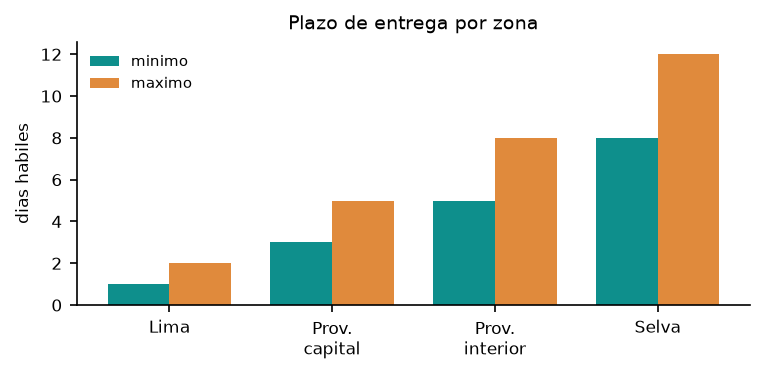

In [10]:
from IPython.display import Image, display

for pagina in doc:
    # get_images() devuelve las imágenes incrustadas. El primer dato de cada una (el
    # xref) es su número interno dentro del PDF; con él se recupera el archivo.
    for indice, info in enumerate(pagina.get_images()):
        xref = info[0]
        imagen = doc.extract_image(xref)
        print(f"Página {pagina.number}, imagen {indice}: "
              f"{imagen['width']}x{imagen['height']} px, formato {imagen['ext']}, "
              f"{len(imagen['image']) / 1024:.0f} KB")
        display(Image(data=imagen["image"], width=420))

Aquí conviene detenerse, porque hay una trampa. Extrajiste la imagen, pero tu sistema RAG
sigue sin saber qué dice. La gráfica contiene información real, los plazos por zona, y para el
buscador es como si no existiera.

Guárdalo como pendiente. En la sección 13 vamos a ver una forma de convertir una imagen en
texto aprovechable, y en el curso volveremos al tema cuando hablemos de documentos con varias
modalidades.

## 10. DOCX, un formato que sí conserva la estructura

Vale la pena ver el contraste. Un archivo de Word no es una pintura de una página como el PDF:
es un documento estructurado, donde los párrafos son párrafos y las tablas son tablas, con
etiquetas que lo dicen explícitamente.

El mismo documento en Word se lee sin nada del trabajo detectivesco de las secciones
anteriores.

In [11]:
from docx import Document

# Un .docx sí conserva la estructura: sabe qué párrafo es un título y qué celdas
# forman una tabla. Por eso, cuando existe el Word original, casi siempre es mejor
# fuente que el PDF que se generó a partir de él.
docx = Document("documentos/tiendasol_politicas.docx")

print(f"Párrafos: {len(docx.paragraphs)}")
print(f"Tablas:   {len(docx.tables)}\n")

print("Primeros párrafos con texto:")
for parrafo in docx.paragraphs[:6]:
    if parrafo.text.strip():
        print(f"  [{parrafo.style.name}] {parrafo.text[:80]}")

print("\nLa tabla, ya con sus filas y columnas:")
for fila in docx.tables[0].rows:
    print("  ", [celda.text for celda in fila.cells])

Párrafos: 11
Tablas:   1

Primeros párrafos con texto:
  [Heading 1] TiendaSol · Politica de envios y devoluciones
  [Normal] Centro de Ayuda · version 1.2 · junio 2026
  [Normal] Este documento reune las condiciones de envio, los plazos de entrega y el proced
  [Normal] Los plazos de entrega se cuentan en dias habiles a partir de la confirmacion del
  [Heading 2] Cuadro 1. Plazos y costos de envio por zona
  [Normal] El cliente puede solicitar la devolucion de un producto dentro de los treinta di

La tabla, ya con sus filas y columnas:
   ['Zona', 'Plazo habil', 'Costo', 'Envio gratis desde']
   ['Lima metropolitana', '1 a 2 dias', 'S/ 9.90', 'S/ 99']
   ['Provincias, capital', '3 a 5 dias', 'S/ 15.90', 'S/ 149']
   ['Provincias, interior', '5 a 8 dias', 'S/ 22.90', 'S/ 199']
   ['Zona de selva', '8 a 12 dias', 'S/ 29.90', 'S/ 249']


Las imágenes del DOCX se sacan de otra forma, y el truco vale la pena conocerlo: un archivo de
Word es en realidad un ZIP con archivos XML y las imágenes adentro. Se puede abrir como
cualquier comprimido y tomar lo que haga falta.

El .docx contiene 18 archivos internos. Algunos:

   [Content_Types].xml
   _rels/.rels
   docProps/core.xml
   docProps/app.xml
   word/document.xml
   word/_rels/document.xml.rels

Imágenes encontradas: 2

   word/media/image1.png  (17 KB)


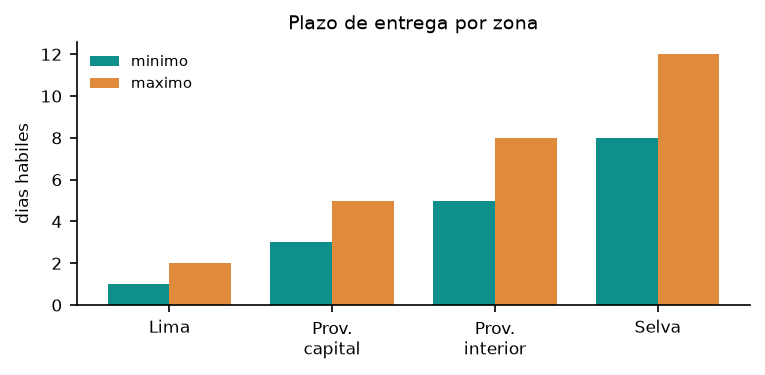

   docProps/thumbnail.jpeg  (8 KB)


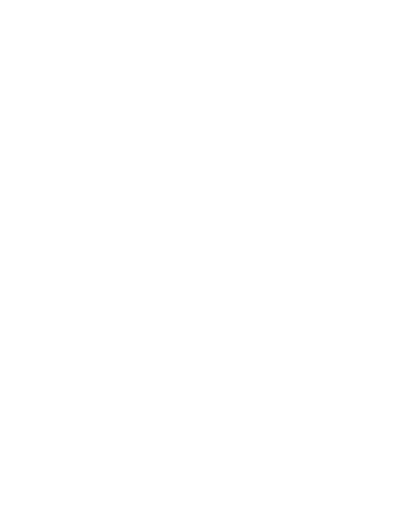

In [12]:
# Un .docx no es un formato misterioso: es una carpeta comprimida con archivos XML
# dentro. Abrirlo como ZIP deja ver las imágenes que lleva pegadas.
import zipfile
from pathlib import PurePosixPath

with zipfile.ZipFile("documentos/tiendasol_politicas.docx") as z:
    internos = z.namelist()
    print(f"El .docx contiene {len(internos)} archivos internos. Algunos:\n")
    for nombre in internos[:6]:
        print(f"   {nombre}")

    imagenes = [n for n in internos
                if PurePosixPath(n).suffix.lower() in (".jpg", ".jpeg", ".png", ".gif")]
    print(f"\nImágenes encontradas: {len(imagenes)}\n")
    for nombre in imagenes:
        datos = z.read(nombre)
        print(f"   {nombre}  ({len(datos) / 1024:.0f} KB)")
        display(Image(data=datos, width=380))

Nota el detalle de `parrafo.style.name` de la celda anterior. El archivo te dice cuál es un
título y cuál es texto normal, sin que tengas que adivinarlo por el tamaño de la letra. Esa
información es oro para fragmentar bien, y la vamos a usar en la sección 15.

La lección práctica: si tienes la opción de conseguir los documentos en un formato estructurado
en lugar de PDF, tómala. Te ahorra la parte más frágil del trabajo. Cuando no haya opción, que
es lo habitual, ya sabes lo que cuesta.

## 11. Metadatos: la información sobre la información

Hasta aquí solo hemos sacado texto. Pero cada fragmento viene de algún lugar, y ese dato vale.

Un metadato es cualquier información sobre el fragmento que no es el fragmento mismo: de qué
documento salió, de qué página, de qué versión, de qué fecha, si era texto corrido o parte de
una tabla.

Sirve para dos cosas muy concretas. La primera es citar la fuente, que es lo que permite al
usuario verificar una respuesta. La segunda es filtrar antes de buscar: si el cliente pregunta
por la política vigente, no quieres que el buscador considere la versión del año pasado. Ese
filtrado no tiene nada que ver con el significado del texto, es una condición dura, como el
`where` de una consulta a una base de datos.

In [13]:
# Le ponemos otro nombre (Fragmento) porque en este cuaderno ya usamos Document para
# los archivos de Word y se confundirían.
from langchain_core.documents import Document as Fragmento

# Ahora sí armamos el corpus. Cada fragmento guarda, además del texto, de dónde salió:
# archivo, página, tipo y versión del documento. Esos metadatos son los que después
# permiten citar la fuente y filtrar por permisos.
fragmentos = []

for pagina in doc:
    tablas_pagina = pagina.find_tables().tables

    for numero, tabla in enumerate(tablas_pagina, 1):
        for frase in tabla_a_frases(tabla.extract()):
            fragmentos.append(Fragmento(
                page_content=frase,
                metadata={"fuente": PDF.name, "pagina": pagina.number,
                          "tipo": "tabla", "tabla": numero, "version": "1.2"},
            ))

texto_pagina = texto_sin_tablas(doc)
fragmentos.append(Fragmento(
    page_content=texto_pagina,
    metadata={"fuente": PDF.name, "tipo": "texto", "version": "1.2"},
))

print(f"Fragmentos con metadatos: {len(fragmentos)}\n")
for f in fragmentos[:3]:
    print(f"  {f.metadata}")
    print(f"    {f.page_content[:70]}\n")

Fragmentos con metadatos: 5

  {'fuente': 'tiendasol_politicas.pdf', 'pagina': 0, 'tipo': 'tabla', 'tabla': 1, 'version': '1.2'}
    Zona: Lima metropolitana; Plazo habil: 1 a 2 dias; Costo: S/ 9.90; Env

  {'fuente': 'tiendasol_politicas.pdf', 'pagina': 0, 'tipo': 'tabla', 'tabla': 1, 'version': '1.2'}
    Zona: Provincias, capital; Plazo habil: 3 a 5 dias; Costo: S/ 15.90; E

  {'fuente': 'tiendasol_politicas.pdf', 'pagina': 0, 'tipo': 'tabla', 'tabla': 1, 'version': '1.2'}
    Zona: Provincias, interior; Plazo habil: 5 a 8 dias; Costo: S/ 22.90; 



## 12. Las hojas de cálculo: el formato que engaña

Falta un formato que casi ninguna empresa se salta, y que tiene una trampa que conviene ver.

Un Excel no es un documento de texto: es una tabla. Y el significado de una celda no está en la
celda, está en el cruce entre su fila y su columna. El número 12.90 no significa nada; lo que
significa algo es "envío estándar a Lima Metropolitana: 12.90".

Vamos a comprobar qué pasa si lo tratamos como si fuera un documento cualquiera.

In [14]:
# Creamos una hoja de cálculo de ejemplo, del tipo que tendría cualquier tienda.
import openpyxl

# Workbook() crea un libro vacío y .active es su primera hoja. append() agrega una
# fila cada vez, empezando por la de encabezados.
libro = openpyxl.Workbook()
hoja = libro.active
hoja.title = "Tarifas"
hoja.append(["Zona", "Envío estándar", "Días hábiles"])   # la fila de encabezados
for fila in [("Lima Metropolitana", 12.90, "3 a 5"),
             ("Provincia costa", 18.50, "5 a 7"),
             ("Provincia sierra", 24.90, "7 a 10")]:
    hoja.append(list(fila))

libro.save("documentos/tarifas.xlsx")
print("Hoja de cálculo creada con 3 zonas y sus tarifas.")

Hoja de cálculo creada con 3 zonas y sus tarifas.


In [15]:
# Ahora la abrimos con la misma herramienta que usamos para los PDF,
# que es lo que haría alguien sin pensarlo mucho.
# Ojo con el resultado de esta celda: no da ningún error, pero lo que devuelve no sirve.
hoja_como_documento = pymupdf.open("documentos/tarifas.xlsx")
texto_plano = " ".join(pagina.get_text() for pagina in hoja_como_documento)

print("Lo que se extrae tratándola como documento:")
print(f"   {texto_plano.strip()}")
print(f"\n   {len(texto_plano.strip())} caracteres")

Lo que se extrae tratándola como documento:
   12.9
18.5
24.9

   14 caracteres


Cuatro números sueltos. Desaparecieron "Lima Metropolitana", "Provincia costa", "Zona", "Envío
estándar" y todo lo demás.

Y esto es **peor que no leer el archivo**. Ese fragmento entra al corpus, el sistema puede
recuperarlo, y el modelo recibe cuatro números sin ninguna referencia a qué corresponden. En el
mejor caso responde que no sabe; en el peor, los asocia a lo que diga la pregunta.

Es un fallo silencioso de los que venimos viendo: nada se rompe, ningún error aparece, y el corpus
queda contaminado sin que nadie se entere.

In [16]:
# La forma correcta: leer la hoja como tabla y convertir cada fila en una frase
# que conserve sus etiquetas.
import pandas as pd


def leer_hoja_de_calculo(ruta):
    """Convierte cada hoja de un Excel en texto donde cada fila lleva sus etiquetas."""
    partes = []
    # sheet_name=None devuelve TODAS las hojas, no solo la primera.
    for nombre_hoja, tabla in pd.read_excel(ruta, sheet_name=None).items():
        lineas = [f"Hoja «{nombre_hoja}» del archivo {Path(ruta).name}:"]
        for _, fila in tabla.iterrows():
            # Cada celda se escribe como "encabezado: valor", que es lo que le da sentido.
            lineas.append("; ".join(f"{columna}: {valor}"
                                    for columna, valor in fila.items()
                                    if pd.notna(valor)))       # se saltan las celdas vacías
        partes.append("\n".join(lineas))
    return "\n\n".join(partes)


texto_util = leer_hoja_de_calculo("documentos/tarifas.xlsx")
print(texto_util)
print(f"\n{len(texto_util)} caracteres, contra {len(texto_plano.strip())} del método anterior.")

Hoja «Tarifas» del archivo tarifas.xlsx:
Zona: Lima Metropolitana; Envío estándar: 12.9; Días hábiles: 3 a 5
Zona: Provincia costa; Envío estándar: 18.5; Días hábiles: 5 a 7
Zona: Provincia sierra; Envío estándar: 24.9; Días hábiles: 7 a 10

240 caracteres, contra 14 del método anterior.


Ahora sí. Cada fila es una frase que se sostiene sola, y una pregunta como "¿cuánto cuesta el
envío a provincia?" tiene dónde encontrar su respuesta.

La lección va más allá del Excel: **cada formato pierde algo distinto al convertirse en texto**.
El PDF pierde el orden de lectura cuando hay dos columnas. El Word pierde los comentarios y el
control de cambios. Una presentación pierde las notas del orador. Y una hoja de cálculo pierde la
estructura, que es justo donde vive el significado.

Cuando alguien proponga un corpus, la pregunta útil no es si el sistema puede leer esos archivos,
sino **qué se pierde al leerlos** y si eso importa para las preguntas que van a hacer los
clientes.

## 13. Parseo con un modelo de visión

Queda pendiente la gráfica. Los modelos que estamos usando no solo leen texto: `gemma3:4b`
también procesa imágenes. Podemos pasarle la gráfica y pedirle que la describa en palabras.

Esto abre una puerta interesante, y también una trampa. Conviene ver las dos.

In [17]:
import base64

import requests

pagina = doc[0]
xref = pagina.get_images()[0][0]
imagen = doc.extract_image(xref)
imagen_b64 = base64.b64encode(imagen["image"]).decode()

peticion = requests.post(
    f"{OLLAMA_URL}/api/generate",
    json={
        "model": "gemma3:4b",
        "prompt": ("Describe the data in this chart. List every category with its values. "
                   "Answer only with the data you can read."),
        "images": [imagen_b64],
        "stream": False,
        "options": {"temperature": 0},
    },
    timeout=300,
)

descripcion = peticion.json()["response"].strip()
print("LO QUE EL MODELO DICE QUE VE:\n")
print(descripcion)

print("\n" + "=" * 78)
print("\nLOS DATOS REALES, extraídos del cuadro con pymupdf:\n")
for fila in tablas.tables[0].extract()[1:]:
    print(f"   {fila[0]:<22} {fila[1]}")

LO QUE EL MODELO DICE QUE VE:

Here’s a breakdown of the data from the chart:

*   **Lima:** Minimum delivery time - 2 days, Maximum delivery time - 3 days
*   **Prov. capital:** Minimum delivery time - 4 days, Maximum delivery time - 6 days
*   **Prov. interior:** Minimum delivery time - 6 days, Maximum delivery time - 8 days
*   **Selva:** Minimum delivery time - 1 day, Maximum delivery time - 12 days


LOS DATOS REALES, extraídos del cuadro con pymupdf:

                          
                          
                          
                          


Compara las dos listas con cuidado, valor por valor.

Lo más probable es que varios plazos no coincidan. En mi corrida el modelo dijo que Lima tarda
de 2 a 3 días cuando el cuadro dice 1 a 2, y que la selva tarda de 1 a 12 días cuando dice de 8
a 12. Leyó la forma general de la gráfica y rellenó los números con lo que le pareció
razonable.

No es un problema de configuración ni de que el modelo sea chico. Es cómo funcionan estos
modelos: generan la descripción más plausible, no la lectura exacta. Un modelo más grande se
equivoca menos, pero sigue sin garantizar el dato.

De ahí la regla práctica: usa el camino más barato que funcione, y deja el modelo de visión
para cuando los demás fallen. Para un PDF con texto seleccionable, `pymupdf` es exacto,
instantáneo y gratis. Para un documento escaneado, o para una infografía sin texto detrás, un
modelo de visión puede ser la única opción, pero conviene revisar lo que produjo.

Y si el dato es crítico, como un precio o un plazo, no lo dejes solo en manos de la imagen.

Un modelo de visión también puede leer una página completa, no solo una figura. Es la salida
para documentos escaneados, donde no hay texto que extraer porque cada página es una fotografía.

Vamos a convertir la página en imagen y a pedirle dos cosas por separado: primero el texto sin
las tablas, y después las tablas en formato de tabla. Separar las peticiones da mejor resultado
que pedir todo junto.

In [18]:
pagina_imagen = doc[0].get_pixmap(dpi=150).tobytes("png")
pagina_b64 = base64.b64encode(pagina_imagen).decode()

INSTRUCCIONES = {
    "texto sin tablas": "Extract the running text from this page. Exclude any tables.",
    "solo las tablas": "Extract the tables from this page. Return them as Markdown tables.",
}

for etiqueta, instruccion in INSTRUCCIONES.items():
    respuesta = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={"model": "gemma3:4b", "prompt": instruccion, "images": [pagina_b64],
              "stream": False, "options": {"temperature": 0}},
        timeout=600,
    ).json()["response"].strip()

    print(f"--- {etiqueta.upper()} ---")
    print(respuesta[:700])
    print()

--- TEXTO SIN TABLAS ---
Here's the extracted text from the image, excluding any tables:

TiendaSol - Política de envíos y devoluciones

Centro de Ayuda : version 1.2 : junio 2026

Este documento reúne las condiciones de envío, los plazos de entrega y el procedimiento de devolución vigentes para todas las compras realizadas en la tienda en línea de TiendaSol. Aplica a pedidos entregados dentro del territorio nacional y complementa los términos y condiciones generales del servicio.

Los plazos de entrega se cuentan en días hábiles a partir de la confirmación del pago, no de la fecha en que se colocó el pedido. Cuando un pedido incluye productos de distinta procedencia, el plazo aplicable es el del producto con mayor 



--- SOLO LAS TABLAS ---
Here are the tables extracted from the image, formatted as Markdown:

**Table 1: Plazos y costos de envío por zona**

| Zona                | Plazo (días) | Costo (S/) | Envío gris desde (S/) |
|---------------------|--------------|------------|-----------------------|
| Lima metropolitana  | 1 a 2        | 9.90       | 99                    |
| Provincias, capital | 3 a 5        | 15.90      | 149                   |
| Provincias, interior| 5 a 8        | 22.90      | 199                   |
| Zona de selva       | 8 a 12       | 29.90      | 249                   |


**Figure 1. Comparación de plazos por zona**

This figure is a graph showing the minimum and maximum delivery times by zone,



Compara este resultado con el de las secciones 5 a 8, donde hicimos lo mismo con `pymupdf`.

Verás que el modelo entrega algo de aspecto muy prolijo, en ocasiones mejor presentado que la
extracción mecánica. Y verás también que se toma libertades: cambia cifras, reordena, resume,
omite. Lo que produce se lee bien, pero no es una copia fiel.

Ahí está el criterio para decidir. Con un PDF que tiene texto seleccionable, `pymupdf` es exacto,
instantáneo y no cuesta nada; usar un modelo de visión sería cambiar precisión por presentación,
un mal negocio. Con un documento escaneado, en cambio, `pymupdf` no devuelve nada y el modelo de
visión es lo único que hay.

La regla que conviene llevarse: prueba primero el camino más barato y quédate con el primero que
funcione. Deja el modelo de visión como último recurso, y cuando lo uses, revisa los datos
críticos a mano.

## 14. Por qué hay que fragmentar

Con el documento ya bien extraído, viene la segunda etapa. ¿Por qué no le pasamos al modelo el
documento completo y nos ahorramos el problema?

Hay tres razones, y la primera es la obvia: no siempre cabe. Cada modelo tiene un límite de
cuánto texto puede recibir de una vez. Pero las otras dos razones son las que de verdad
importan, y las puedes medir tú.

La segunda es el tiempo, y conviene medirlo bien. Si cronometras la llamada completa, lo que
mides es sobre todo cuántas palabras decidió escribir el modelo, que varía de una corrida a
otra. Lo que nos interesa aislar es cuánto tarda en leer el contexto.

Ollama informa eso por separado. Le pedimos que genere un solo token, con `num_predict`, y
leemos el dato que devuelve sobre el tiempo dedicado a procesar el texto de entrada.

In [19]:
# num_predict=1 le pide al modelo que escriba una sola palabra: no interesa la
# respuesta, sino cuánto texto alcanzó a LEER, que es lo que devuelve prompt_eval_count.
def medir_lectura(texto, num_ctx=None):
    """Devuelve cuántos tokens leyó el modelo y cuánto tardó en leerlos."""
    opciones = {"num_predict": 1, "temperature": 0}
    if num_ctx:
        opciones["num_ctx"] = num_ctx

    respuesta = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={"model": MODELO_LLM, "prompt": texto, "stream": False, "options": opciones},
        timeout=900,
    ).json()

    return (respuesta.get("prompt_eval_count", 0),
            respuesta.get("prompt_eval_duration", 0) / 1e9)


base = corrido * 10   # repetimos el documento para tener material de sobra

print(f"{'caracteres':>11} {'tokens':>8} {'segundos':>9} {'ms por token':>14}")
print("-" * 46)
# Le damos textos cada vez más largos para ver cómo crece el tiempo de lectura.
for tamano in (500, 2000, 5000, 10000):
    tokens, segundos = medir_lectura(base[:tamano])
    print(f"{tamano:>11} {tokens:>8} {segundos:>9.2f} "
          f"{1000 * segundos / max(tokens, 1):>14.2f}")

 caracteres   tokens  segundos   ms por token
----------------------------------------------


        500      130      0.22           1.67


       2000      469      0.68           1.45


       5000     1165      1.63           1.40


      10000     2305      1.64           0.71


Ahora sí se ve el patrón: el tiempo de lectura crece con el texto, y en un chat de atención a
clientes esos segundos son la diferencia entre un servicio que se siente ágil y uno que se
siente roto.

Pero hay algo más grave que la lentitud, y lo vamos a comprobar ahora.

In [20]:
texto_largo = base[:20000]
tokens_estimados = len(texto_largo) // 4   # regla gruesa: un token son unos 4 caracteres

tokens_leidos, segundos = medir_lectura(texto_largo)

print(f"Le mandamos     {len(texto_largo):>6} caracteres, unos {tokens_estimados} tokens")
print(f"El modelo leyó  {tokens_leidos:>6} tokens en {segundos:.2f} s")

# Si el modelo leyó bastante menos de lo que le mandamos, es que el texto no cupo en su
# ventana de contexto. Este es el fallo silencioso del que habla la sesión 4.
perdido = 1 - tokens_leidos / tokens_estimados
if perdido > 0.1:
    print(f"\nSe quedó fuera cerca del {100 * perdido:.0f}% del texto.")
    print("No hubo error, ni advertencia, ni nada. Simplemente no lo vio.")
else:
    print("\nEn este caso entró completo.")

Le mandamos      20000 caracteres, unos 5000 tokens
El modelo leyó    2051 tokens en 2.84 s

Se quedó fuera cerca del 59% del texto.
No hubo error, ni advertencia, ni nada. Simplemente no lo vio.


Esto es lo más importante de la sección, y la razón por la que fragmentar no es opcional.

Cada modelo tiene una ventana de contexto, que es cuánto texto puede tener presente a la vez.
Cuando le mandas más, no falla: recorta y sigue como si nada. No hay excepción, no hay mensaje
en rojo, no hay nada que revisar en un registro. La respuesta llega con su tono seguro de
siempre, construida sobre un texto al que le faltaba la mitad.

Piensa en lo que significa en un sistema real. Un fragmento largo con la política de
devoluciones completa entra al índice, se recupera para la pregunta correcta, se le pasa al
modelo, y el modelo contesta habiendo leído solo el principio. El sistema no se rompe. Solo
responde mal, de vez en cuando, por razones que no aparecen en ninguna parte.

La ventana se puede ampliar, y vale la pena ver lo que cuesta.

In [21]:
print(f"{'configuración':<24} {'tokens leídos':>14} {'segundos':>10}")
print("-" * 50)
# num_ctx es el tamaño de la ventana de contexto. Subirlo hace que quepa más texto, a
# cambio de memoria y de tiempo. None deja el valor por omisión de Ollama.
for ventana in (None, 8192):
    tokens, segundos = medir_lectura(texto_largo, num_ctx=ventana)
    etiqueta = f"num_ctx = {ventana}" if ventana else "por omisión"
    print(f"{etiqueta:<24} {tokens:>14} {segundos:>10.2f}")

configuración             tokens leídos   segundos
--------------------------------------------------


por omisión                        2051       0.02


num_ctx = 8192                     4609       6.39


Ampliando la ventana entra todo el texto, y el tiempo de lectura sube en proporción. Además
crece la memoria que ocupa el modelo, que es lo que hace que un equipo modesto se atore.

Así que no es que fragmentar sea la única salida. Es que es la barata: en lugar de pagar por
leer un documento entero en cada pregunta, y arriesgarte a que se corte, mandas los tres o
cuatro pedazos que hacen falta.

Queda una tercera razón, la menos intuitiva. Cuando un fragmento habla de muchos temas a la
vez, el vector que lo representa acaba siendo un promedio de todos ellos y no representa bien a
ninguno. Fragmentos cortos y centrados en un solo asunto se encuentran con más precisión. Es
decir, fragmentar no solo evita el truncado y ahorra tiempo: también mejora la búsqueda.

## 15. Cuatro maneras de fragmentar

No hay una forma correcta. Hay cuatro estrategias comunes, cada una con un criterio distinto
sobre dónde conviene cortar.

In [22]:
import spacy
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Los dos números que gobiernan toda la fragmentación: cuánto mide cada trozo y cuánto
# comparten dos trozos vecinos. Se escriben aquí arriba para poder cambiarlos en un
# solo lugar y ver el efecto en las cuatro estrategias a la vez.
TAMANO = 500
TRASLAPE = 100

# --- 1. Tamaño fijo: cortar cada N caracteres, sin mirar el contenido -------
# La estrategia más simple: cortar cada 500 caracteres pase lo que pase. Es rápida y
# predecible, pero parte palabras y frases por la mitad.
def fragmentar_fijo(texto, tamano=TAMANO, traslape=TRASLAPE):
    paso = tamano - traslape
    return [texto[i:i + tamano] for i in range(0, len(texto), paso)]


# --- 2. Por oraciones: cortar donde termina una oración de verdad -----------
# El modelo tiene que ser del idioma del documento. Más abajo verás por qué.
nlp = spacy.load("es_core_news_sm")
nlp.max_length = 2_000_000

# Aquí se van juntando oraciones completas hasta llegar al tamaño. Nunca se corta a
# media frase, pero los trozos quedan de largos desiguales.
def fragmentar_oraciones(texto, tamano=TAMANO):
    oraciones = [s.text.strip() for s in nlp(texto).sents]
    fragmentos, actual = [], ""
    for oracion in oraciones:
        if len(actual) + len(oracion) + 1 <= tamano:
            actual = f"{actual} {oracion}".strip()
        else:
            if actual:
                fragmentos.append(actual)
            actual = oracion
    if actual:
        fragmentos.append(actual)
    return fragmentos


# --- 3. Recursiva: probar separadores en orden, del más grande al más chico --
recursivo = RecursiveCharacterTextSplitter(
    chunk_size=TAMANO, chunk_overlap=TRASLAPE, length_function=len
)

# --- 4. Por estructura: usar los títulos del documento como frontera --------
# La cuarta usa los títulos del documento como frontera natural. Es la que mejor
# respeta el sentido, pero solo funciona si el documento tiene títulos de verdad,
# marcados con estilos, y no texto puesto en negritas a mano.
def fragmentar_por_estructura(ruta_docx):
    documento = Document(ruta_docx)
    secciones, titulo, cuerpo = [], "Introducción", []
    for parrafo in documento.paragraphs:
        if not parrafo.text.strip():
            continue
        if parrafo.style.name.startswith("Heading"):
            if cuerpo:
                secciones.append((titulo, " ".join(cuerpo)))
                cuerpo = []
            titulo = parrafo.text.strip()
        else:
            cuerpo.append(parrafo.text.strip())
    if cuerpo:
        secciones.append((titulo, " ".join(cuerpo)))
    return secciones


print("Las cuatro funciones están listas.")

Las cuatro funciones están listas.


Antes de comparar, una advertencia sobre la segunda estrategia que cuesta caro aprender en
producción. El modelo de spaCy tiene que ser del idioma del documento. Mira lo que pasa cuando
no lo es.

In [23]:
prueba = ("El cliente puede solicitar la devolucion dentro de los treinta dias. "
          "El Sr. Perez pidio el art. 5 del reglamento.")

# La misma frase, partida por el modelo de inglés y por el de español. La diferencia
# está en abreviaturas como "Sr." y "art.": el modelo equivocado ve ahí un punto final
# y corta la oración donde no debe.
for etiqueta, nombre_modelo in [("inglés", "en_core_web_sm"), ("español", "es_core_news_sm")]:
    modelo = spacy.load(nombre_modelo)
    oraciones = [s.text for s in modelo(prueba).sents]
    print(f"Modelo en {etiqueta}: encontró {len(oraciones)} oraciones")
    for oracion in oraciones:
        print(f"     · {oracion}")
    print()

Modelo en inglés: encontró 4 oraciones
     · El cliente puede solicitar la devolucion dentro de los treinta dias.
     · El Sr.
     · Perez pidio el art.
     · 5 del reglamento.



Modelo en español: encontró 3 oraciones
     · El cliente puede solicitar la devolucion dentro de los treinta dias.
     · El Sr. Perez pidio el art.
     · 5 del reglamento.



El modelo en inglés no conoce las abreviaturas del español, así que ve un punto en "Sr." y corta
ahí, inventando una oración que no existe. El de español reconoce "Sr." y no se deja engañar.

Fíjate también en que ninguno de los dos es perfecto: los dos parten en "art. 5". La detección
de oraciones se rompe con abreviaturas, iniciales, números con punto y decimales, y por eso
conviene no fiarse de ella como si fuera exacta.

Traducido a decisión práctica: si eliges fragmentar por oraciones, tienes que instalar un modelo
por cada idioma con el que trabajes. Con documentos en varios idiomas, o con documentos que
mezclan idiomas en la misma página, esta estrategia se vuelve incómoda rápido.

## 16. Comparar las cuatro

Ahora corremos las cuatro sobre el mismo texto y miramos qué produce cada una. Lo interesante
no es cuántos fragmentos genera, sino por dónde corta.

In [24]:
# Las cuatro estrategias sobre el mismo texto, para compararlas en igualdad de condiciones.
fijos = fragmentar_fijo(corrido)
oraciones = fragmentar_oraciones(corrido)
recursivos = recursivo.split_text(corrido)
estructurados = fragmentar_por_estructura("documentos/tiendasol_politicas.docx")

print(f"{'estrategia':<24} {'trozos':>7} {'promedio':>9} {'mín':>6} {'máx':>6}")
print("-" * 56)
for nombre, trozos in [("tamaño fijo", fijos), ("por oraciones", oraciones),
                       ("recursiva", recursivos),
                       ("por estructura", [t for _, t in estructurados])]:
    largos = [len(t) for t in trozos]
    print(f"{nombre:<24} {len(trozos):>7} {sum(largos) // len(largos):>9} "
          f"{min(largos):>6} {max(largos):>6}")

print("\nDónde corta cada una. Fíjate en el final de cada fragmento:\n")
for nombre, trozos in [("TAMAÑO FIJO", fijos), ("POR ORACIONES", oraciones),
                       ("RECURSIVA", recursivos)]:
    print(f"{nombre}")
    print(f"   ...{trozos[0][-70:]!r}")
    print()

estrategia                trozos  promedio    mín    máx
--------------------------------------------------------
tamaño fijo                    6       439    136    500
por oraciones                  5       426    357    492
recursiva                      6       382    124    487
por estructura                 3       667    608    699

Dónde corta cada una. Fíjate en el final de cada fragmento:

TAMAÑO FIJO
   ...'dias habiles a partir de la confirmacion del pago, no de la fecha en q'

POR ORACIONES
   ...'ional y complementa los terminos y condiciones generales del servicio.'

RECURSIVA
   ...'ional y complementa los terminos y condiciones generales del servicio.'



Ahí está la diferencia, y se ve en el corte del primer fragmento.

El tamaño fijo corta en el carácter 500, sin importar qué haya ahí. Suele partir una palabra a
la mitad. A cambio es la más rápida, la más predecible y la más fácil de explicar.

Por oraciones nunca parte una idea a media frase. Es la que produce fragmentos más legibles, y
la que más cuesta: hay que cargar un modelo de lenguaje solo para saber dónde termina una
oración. Y la segmentación falla en abreviaturas, iniciales y números con punto.

La recursiva intenta cortar primero entre párrafos; si el pedazo sigue siendo grande, entre
oraciones; y si no queda remedio, a la fuerza. Es el punto medio razonable, y por eso es la que
usamos en la práctica 1 y la que verás por omisión en casi cualquier proyecto.

La de estructura es distinta de las otras tres, porque no razona sobre longitud sino sobre el
documento: cada sección con su título es un fragmento. Cuando el documento está bien
organizado, como una política con apartados numerados, es la que da mejores resultados, porque
respeta las fronteras que puso quien lo escribió. Cuando el documento no tiene estructura, no
sirve de nada.

In [25]:
print("Fragmentos por estructura, con el título como contexto:\n")
for titulo, cuerpo in estructurados:
    print(f"[{titulo}]  {len(cuerpo)} caracteres")
    print(f"   {cuerpo[:110]}...\n")

Fragmentos por estructura, con el título como contexto:

[TiendaSol · Politica de envios y devoluciones]  695 caracteres
   Centro de Ayuda · version 1.2 · junio 2026 Este documento reune las condiciones de envio, los plazos de entreg...

[Cuadro 1. Plazos y costos de envio por zona]  699 caracteres
   El cliente puede solicitar la devolucion de un producto dentro de los treinta dias calendario siguientes a la ...

[Figura 1. Comparacion de plazos por zona]  608 caracteres
   Los gastos de envio de la devolucion corren por cuenta de TiendaSol unicamente cuando el motivo es un error de...



Nota lo que trae de regalo esta última: el título. Guardarlo junto al fragmento le da al
buscador y al modelo un contexto que el texto suelto no tiene. Un fragmento que empieza con
"Cuadro 1. Plazos y costos de envío por zona" es mucho más fácil de encontrar que el mismo
texto sin encabezado.

## 17. Cuál elegir, y por qué esta comparación no alcanza para decidir

Medí las cuatro estrategias con este documento, seis preguntas de cliente cuyo pasaje correcto
conozco, y el buscador trayendo tres fragmentos. El resultado fue este:

| Estrategia | Fragmentos | Pasajes correctos |
|---|---|---|
| Tamaño fijo, 500 con 100 | 6 | 6 de 6 |
| Recursiva, 500 con 100 | 6 | 6 de 6 |
| Recursiva, 1000 con 200 | 3 | 6 de 6 |
| Por estructura | 3 | 6 de 6 |
| Por oraciones | 5 | 5 de 6 |

Cuatro empatadas en el máximo. Antes de concluir que da igual, mira por qué: el documento genera
entre tres y seis fragmentos, y le estamos pidiendo tres. Es decir, en cada consulta recuperamos
entre la mitad y todo el corpus. Con esas condiciones cualquier estrategia acierta, porque es
casi imposible fallar.

La medición no está mal hecha, está mal dimensionada. Para que una comparación de estrategias
signifique algo hace falta un corpus de cientos de fragmentos, donde traer tres sea de verdad
una selección, y decenas de preguntas para que una sola no mueva el resultado.

Guárdate ese razonamiento más que la tabla. Es el que te va a servir cuando alguien te presente
una comparación con números convincentes: preguntar cuántos casos tenía y qué tan fácil era
acertar por casualidad.

Para el resto del curso nos quedamos con la **recursiva**, y las razones son prácticas más que de
desempeño. Funciona igual de bien que las demás en la medición, no necesita instalar un modelo de
idioma por cada idioma, no depende de que el documento tenga títulos bien puestos, y respeta los
párrafos cuando existen. Es la opción que menos supuestos hace sobre el material que le llegue.

Sobre el tamaño: en la práctica 1 usamos 1000 con 200 de traslape porque la novela es prosa
corrida, donde una idea puede ocupar varios párrafos. En un documento de políticas como este,
donde cada apartado es breve y autocontenido, 500 con 100 va mejor. El tamaño se ajusta al
material, no al revés.

## 18. El traslape no es gratis

Volvamos sobre el traslape, porque lo presenté como una buena idea sin decir lo que cuesta.

El argumento a favor es real: repetir el final de un fragmento al principio del siguiente evita
que una idea quede partida en la frontera y no se encuentre en ninguno de los dos. Pero eso se
paga, y se paga en el lugar más escaso del sistema, que es el espacio en el prompt.

In [26]:
# El traslape tiene un precio: el texto compartido se guarda dos veces. Esta celda mide
# cuánto crece el corpus con cada valor, que es lo que se paga en disco, en tiempo de
# indexado y en fragmentos casi iguales compitiendo entre sí en la búsqueda.
def duplicacion(texto, tamano, traslape):
    """Cuánto texto se repite al fragmentar con traslape."""
    divisor = RecursiveCharacterTextSplitter(chunk_size=tamano, chunk_overlap=traslape)
    trozos = divisor.split_text(texto)
    caracteres_totales = sum(len(t) for t in trozos)
    return len(trozos), caracteres_totales


original = len(corrido)
print(f"El texto original mide {original} caracteres.\n")
print(f"{'traslape':>9} {'trozos':>7} {'caracteres guardados':>21} {'inflación':>11}")
print("-" * 52)
for traslape in (0, 50, 100, 200):
    trozos, total = duplicacion(corrido, 500, traslape)
    print(f"{traslape:>9} {trozos:>7} {total:>21} {100 * (total / original - 1):>10.1f}%")

El texto original mide 2136 caracteres.

 traslape  trozos  caracteres guardados   inflación
----------------------------------------------------
        0       6                  2130       -0.3%
       50       6                  2174        1.8%
      100       6                  2294        7.4%
      200       7                  2770       29.7%


Fíjate en la última columna, y en algo que quizá no esperabas: con 100 de traslape la inflación es
bastante menor que el 20% que uno calcularía a mano. La razón es que el divisor recursivo no aplica
el traslape a ciegas, corta en fronteras naturales, así que el traslape efectivo termina siendo más
chico que el que pediste. En cambio con 200 el crecimiento sí se dispara.

Ese exceso no se queda en el disco. Cuando la búsqueda recupera dos fragmentos vecinos, el modelo
recibe dos veces el mismo párrafo, ocupando lugar que podría llevar información nueva.

Hay una investigación de Chroma que midió esto con cuidado, evaluando estrategias de segmentación
no por documentos recuperados sino por tokens útiles. Sus dos hallazgos que nos importan: quitar
el traslape mejora de forma clara la proporción de tokens aprovechados, y bajar el tamaño de
fragmento de 400 a 200 tokens mejora la precisión manteniendo el recall cerca del 88%. También
encontraron que los valores por omisión que traen algunas librerías, 800 tokens con 400 de
traslape, quedan por debajo del promedio en casi todo.

Así que la recomendación honesta es más matizada de lo que dije antes. El traslape ayuda cuando
los cortes caen en mal lugar, y sobra cuando la fragmentación ya respeta las fronteras naturales
del texto. Si fragmentas por estructura o por oraciones, el traslape casi no aporta. Si cortas por
tamaño fijo, sí.

Y como todo en esta etapa, se mide. En este documento cualquiera de las dos opciones responde igual
de bien, porque es corto; con un corpus de miles de fragmentos, el espacio desperdiciado en cada
consulta se nota en el tiempo de respuesta y en el costo.

Nota de paso lo que acabas de hacer, porque es un hábito que vale más que el dato: tenías una
creencia sobre cuánto infla el traslape, la mediste, y el número resultó distinto del que
calculabas de cabeza. Ese es el trabajo.

## 19. Lo que preparaste

Empezaste con un PDF donde el cuadro de plazos era una lista de valores sin sentido, y
terminaste con fragmentos que se sostienen solos, cada uno con su origen anotado.

Ese es todo el trabajo del flujo de ingesta, y conviene apreciar lo poco glamoroso que es. No
hay modelo grande, no hay prompt ingenioso, no hay nada que presumir. Y sin embargo es donde se
gana o se pierde la calidad del sistema completo, porque todo lo que venga después solo puede
trabajar con lo que le hayas dejado aquí.

Tres ideas para llevarte:

Separa por tipo de contenido en lugar de limpiar a ciegas. El texto corrido y las tablas
necesitan tratamientos distintos, y mezclarlos arruina los dos.

Guarda de dónde salió cada fragmento. Cuesta dos líneas al fragmentar y es lo que después
permite citar la fuente y filtrar por versión.

Y cualquier cambio en esta etapa hay que medirlo. En la práctica 1 viste que unir los saltos de
línea de un PDF, que parecía una mejora obvia, hacía que la búsqueda perdiera un pasaje que
antes encontraba.

En la práctica siguiente tomamos estos fragmentos y armamos la otra mitad: convertirlos en
vectores, buscar entre ellos y evaluar si las respuestas son buenas.